# Analiza i porównanie najlepszych konfiguracji parametrów

In [1]:
import os
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Topologia meeting

In [17]:
sns.set_theme(style="darkgrid")

# ============================================================
# LOAD RESULTS
# ============================================================

RESULTS_PATH = "./best_configs_new"

files = glob.glob(os.path.join(RESULTS_PATH, "meeting*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_meeting = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_meeting)}")

display(df_meeting.head())

print("\nColumns:")
print(df_meeting.columns.tolist())

Loaded files:
meeting_n500_array_20315406.csv
meeting_n300_array_20315406.csv

Total rows: 30


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file
0,2,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,63.818691,47.183104,meeting_n500_array_20315406.csv
1,1,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,62.138087,49.713811,meeting_n500_array_20315406.csv
2,0,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,61.609376,48.553628,meeting_n500_array_20315406.csv
3,3,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,61.446657,47.567721,meeting_n500_array_20315406.csv
4,4,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,123,62.282137,50.902658,meeting_n500_array_20315406.csv



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'z_star', 'n_steps', 'r0', 'r1', 'gamma', 'build_target_ratio', 'seed', 'average', 'best', 'source_file']


In [18]:
df_meeting

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,average,best,source_file
0,2,meeting,500,5,5,10,1000,0.00050,1.0,0.005,0.8,123,63.818691,47.183104,meeting_n500_array_20315406.csv
1,1,meeting,500,5,5,10,1000,0.00050,1.0,0.005,0.8,123,62.138087,49.713811,meeting_n500_array_20315406.csv
2,0,meeting,500,5,5,10,1000,0.00050,1.0,0.005,0.8,123,61.609376,48.553628,meeting_n500_array_20315406.csv
3,3,meeting,500,5,5,10,1000,0.00050,1.0,0.005,0.8,123,61.446657,47.567721,meeting_n500_array_20315406.csv
4,4,meeting,500,5,5,10,1000,0.00050,1.0,0.005,0.8,123,62.282137,50.902658,meeting_n500_array_20315406.csv
5,6,meeting,500,5,5,10,1000,0.00100,1.0,0.005,0.8,123,73.703726,54.222845,meeting_n500_array_20315406.csv
6,7,meeting,500,5,5,10,1000,0.00100,1.0,0.005,0.8,123,74.443058,54.583364,meeting_n500_array_20315406.csv
7,5,meeting,500,5,5,10,1000,0.00100,1.0,0.005,0.8,123,63.819355,49.104965,meeting_n500_array_20315406.csv
8,10,meeting,500,5,5,10,500,0.00100,1.0,0.001,0.8,123,65.926875,57.113170,meeting_n500_array_20315406.csv
9,11,meeting,500,5,5,10,500,0.00100,1.0,0.001,0.8,123,65.926875,57.113170,meeting_n500_array_20315406.csv


In [19]:
# tworzymy nową kolumnę config_id do łatwego grupowania wyników

config_cols = [
    "number_of_islands",
    "number_of_islands",
    "migration_interval",
    "z_star",
    "n_steps",
    "r0",
    "r1",
    "gamma"

]

df_meeting["config_id"] = (
    df_meeting[config_cols]
    .astype(str)
    .agg("_".join, axis=1)
)

In [21]:
meeting_summary = (
    df_meeting
    .groupby(["config_id","topology","number_of_islands"], as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

meeting_summary

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,300_300_5_10_1000_0.00025_2.0_0.005,meeting,300,88.673335,7.465663,77.825988,97.149535,89.918102,115.701104,11.874377,98.002157,125.707431,121.789988
1,300_300_5_10_1000_0.001_2.0_0.005,meeting,300,80.891533,5.400148,75.975925,88.879210,80.128208,105.646160,6.156441,99.245399,113.058927,104.486511
2,300_300_5_10_500_0.001_1.0_0.001,meeting,300,88.245977,5.914922,79.930516,94.654200,89.268795,111.343845,11.326437,95.550640,121.241029,117.113138
3,500_500_5_10_1000_0.0005_1.0_0.005,meeting,500,48.784184,1.536924,47.183104,50.902658,48.553628,62.258990,0.939375,61.446657,63.818691,62.138087
4,500_500_5_10_1000_0.001_1.0_0.005,meeting,500,51.875437,6.818036,41.710437,59.755573,54.222845,68.962387,7.343636,58.553682,74.443058,73.703726
5,500_500_5_10_500_0.001_1.0_0.001,meeting,500,53.781570,3.517976,50.116776,57.113170,54.447959,63.589115,3.069008,60.220258,65.926875,65.632274


In [22]:
meeting_summary.sort_values("mean_best")

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
3,500_500_5_10_1000_0.0005_1.0_0.005,meeting,500,48.784184,1.536924,47.183104,50.902658,48.553628,62.258990,0.939375,61.446657,63.818691,62.138087
4,500_500_5_10_1000_0.001_1.0_0.005,meeting,500,51.875437,6.818036,41.710437,59.755573,54.222845,68.962387,7.343636,58.553682,74.443058,73.703726
5,500_500_5_10_500_0.001_1.0_0.001,meeting,500,53.781570,3.517976,50.116776,57.113170,54.447959,63.589115,3.069008,60.220258,65.926875,65.632274
1,300_300_5_10_1000_0.001_2.0_0.005,meeting,300,80.891533,5.400148,75.975925,88.879210,80.128208,105.646160,6.156441,99.245399,113.058927,104.486511
2,300_300_5_10_500_0.001_1.0_0.001,meeting,300,88.245977,5.914922,79.930516,94.654200,89.268795,111.343845,11.326437,95.550640,121.241029,117.113138
0,300_300_5_10_1000_0.00025_2.0_0.005,meeting,300,88.673335,7.465663,77.825988,97.149535,89.918102,115.701104,11.874377,98.002157,125.707431,121.789988


In [24]:
meeting_summary.sort_values("median_best")

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
3,500_500_5_10_1000_0.0005_1.0_0.005,meeting,500,48.784184,1.536924,47.183104,50.902658,48.553628,62.258990,0.939375,61.446657,63.818691,62.138087
4,500_500_5_10_1000_0.001_1.0_0.005,meeting,500,51.875437,6.818036,41.710437,59.755573,54.222845,68.962387,7.343636,58.553682,74.443058,73.703726
5,500_500_5_10_500_0.001_1.0_0.001,meeting,500,53.781570,3.517976,50.116776,57.113170,54.447959,63.589115,3.069008,60.220258,65.926875,65.632274
1,300_300_5_10_1000_0.001_2.0_0.005,meeting,300,80.891533,5.400148,75.975925,88.879210,80.128208,105.646160,6.156441,99.245399,113.058927,104.486511
2,300_300_5_10_500_0.001_1.0_0.001,meeting,300,88.245977,5.914922,79.930516,94.654200,89.268795,111.343845,11.326437,95.550640,121.241029,117.113138
0,300_300_5_10_1000_0.00025_2.0_0.005,meeting,300,88.673335,7.465663,77.825988,97.149535,89.918102,115.701104,11.874377,98.002157,125.707431,121.789988


<Axes: xlabel='number_of_islands', ylabel='best'>

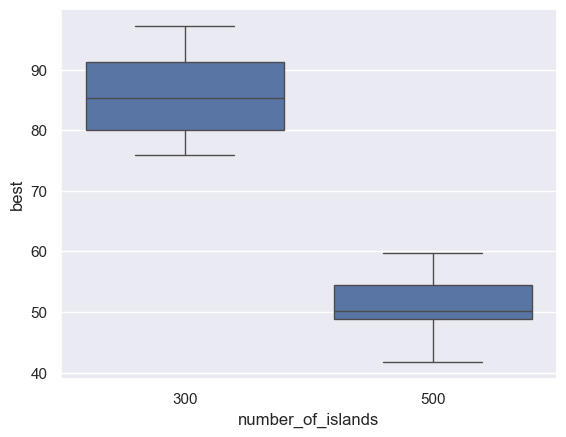

In [25]:
sns.boxplot(
    data=df_meeting,
    x="number_of_islands",
    y="best"
)

## Scale-free topology

In [2]:
RESULTS_PATH = "./best_configs_new"

files = glob.glob(os.path.join(RESULTS_PATH, "scale_free*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_scale_free = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_scale_free)}")

display(df_scale_free.head())

Loaded files:
scale_free_n200_array_20313659.csv
scale_free_n300_array_20313659.csv
scale_free_n50_array_20313659.csv
scale_free_n500_array_20313659.csv
scale_free_n100_array_20313659.csv

Total rows: 75


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file
0,30,scale_free,200,5,5,15,14,123,147.098527,80.315462,scale_free_n200_array_20313659.csv
1,31,scale_free,200,5,5,15,14,123,152.691503,80.705968,scale_free_n200_array_20313659.csv
2,32,scale_free,200,5,5,15,14,123,153.905586,79.036419,scale_free_n200_array_20313659.csv
3,33,scale_free,200,5,5,15,14,123,154.768352,90.291510,scale_free_n200_array_20313659.csv
4,34,scale_free,200,5,5,15,14,123,139.132327,71.164097,scale_free_n200_array_20313659.csv


In [3]:
config_cols = [
    "number_of_islands",
    "number_of_islands",
    "migration_interval",
    "m0",
    "m"
]

df_scale_free["config_id"] = (
    df_scale_free[config_cols]
    .astype(str)
    .agg("_".join, axis=1)
)

In [10]:
df_scale_free

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,config_id
0,30,scale_free,200,5,5,15,14,123,147.098527,80.315462,scale_free_n200_array_20313659.csv,200_200_5_15_14
1,31,scale_free,200,5,5,15,14,123,152.691503,80.705968,scale_free_n200_array_20313659.csv,200_200_5_15_14
2,32,scale_free,200,5,5,15,14,123,153.905586,79.036419,scale_free_n200_array_20313659.csv,200_200_5_15_14
3,33,scale_free,200,5,5,15,14,123,154.768352,90.291510,scale_free_n200_array_20313659.csv,200_200_5_15_14
4,34,scale_free,200,5,5,15,14,123,139.132327,71.164097,scale_free_n200_array_20313659.csv,200_200_5_15_14
...,...,...,...,...,...,...,...,...,...,...,...,...
70,55,scale_free,100,5,5,20,13,123,179.184287,127.277825,scale_free_n100_array_20313659.csv,100_100_5_20_13
71,56,scale_free,100,5,5,20,13,123,212.740723,145.044397,scale_free_n100_array_20313659.csv,100_100_5_20_13
72,59,scale_free,100,5,5,20,13,123,212.892030,139.555531,scale_free_n100_array_20313659.csv,100_100_5_20_13
73,57,scale_free,100,5,5,20,13,123,210.908170,135.158048,scale_free_n100_array_20313659.csv,100_100_5_20_13


In [26]:
scale_free_summary = (
    df_scale_free
    .groupby(["config_id","topology","number_of_islands"], as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

scale_free_summary

,config_id,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,100_100_5_20_13,scale_free,100,139.742250,9.312970,127.277825,151.675449,139.555531,206.053124,15.075100,179.184287,214.540411,212.740723
1,100_100_5_20_15,scale_free,100,145.285548,7.080622,136.608439,154.127461,147.368166,200.646857,8.447857,189.248335,211.984340,202.108526
2,100_100_5_20_16,scale_free,100,136.432096,11.942419,126.880463,154.129889,129.483435,188.261924,11.339419,176.294838,206.108014,183.758137
3,200_200_5_12_11,scale_free,200,76.414904,5.610225,69.568359,81.772324,79.256173,148.318257,9.558900,134.974849,158.129228,151.375686
4,200_200_5_15_14,scale_free,200,80.302691,6.801776,71.164097,90.291510,80.315462,149.519259,6.530779,139.132327,154.768352,152.691503
5,200_200_5_15_15,scale_free,200,76.476043,4.023665,70.087553,80.999886,77.588128,142.482966,10.075900,129.653547,154.245161,146.951756
6,300_300_5_15_15,scale_free,300,45.463471,4.411655,39.963290,50.262052,45.787259,124.410201,4.248353,118.295679,129.625247,124.019410
7,300_300_5_8_7,scale_free,300,58.583119,7.136624,53.168214,67.371334,53.869526,188.552153,4.211220,181.929196,192.373979,188.204463
8,300_300_5_8_8,scale_free,300,53.409776,6.992164,47.076793,61.106656,50.594551,168.781515,9.872770,159.512365,182.699583,165.761974
9,500_500_5_15_14,scale_free,500,24.137909,2.955835,20.701186,28.784801,23.315194,99.441686,7.250177,93.906362,110.604909,94.846973


<Axes: xlabel='number_of_islands', ylabel='best'>

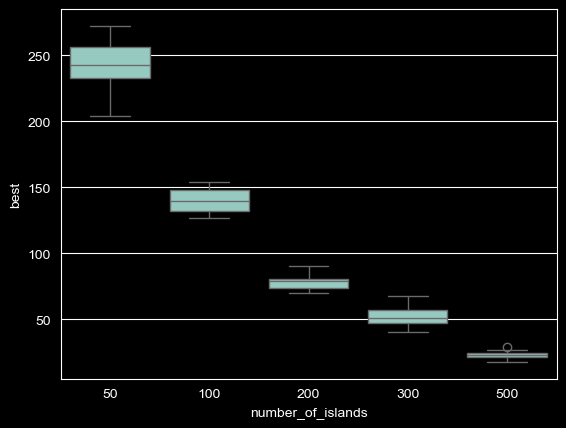

In [8]:
sns.boxplot(
    data=df_scale_free,
    x="number_of_islands",
    y="best"
)

## Complete topology

In [4]:
RESULTS_PATH = "./best_configs_new"

files = glob.glob(os.path.join(RESULTS_PATH, "complete*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_complete = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_complete)}")

display(df_complete.head())

Loaded files:
complete_n500_array_20315054.csv
complete_n100_array_20315054.csv
complete_n200_array_20315054.csv
complete_n300_array_20315054.csv
complete_n50_array_20315054.csv

Total rows: 25


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,average,best,source_file
0,20,complete,500,5,5,52.482854,42.093114,complete_n500_array_20315054.csv
1,21,complete,500,5,5,52.482854,42.093114,complete_n500_array_20315054.csv
2,22,complete,500,5,5,94.491498,52.269432,complete_n500_array_20315054.csv
3,23,complete,500,5,5,57.367060,42.470960,complete_n500_array_20315054.csv
4,24,complete,500,5,5,69.486343,49.055172,complete_n500_array_20315054.csv


In [11]:
complete_summary = (
    df_complete
    .groupby(["topology","number_of_islands"], as_index=False)
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

complete_summary

,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,complete,50,238.240552,2.273440,235.777742,240.158113,239.331050,269.214739,2.023646,265.703022,270.727155,269.886729
1,complete,100,143.733269,7.957138,137.144861,152.621582,139.622431,195.639476,5.798808,188.735106,202.246417,195.439627
2,complete,200,99.548170,2.318905,95.921994,101.343986,100.542587,145.865687,4.230812,139.420650,150.167057,147.732975
3,complete,300,75.328563,9.453703,65.645665,87.388268,70.234101,102.361683,21.582584,82.305031,137.123448,101.678400
4,complete,500,45.596358,4.764631,42.093114,52.269432,42.470960,65.262122,17.756350,52.482854,94.491498,57.367060


# Porównanie 3 najlepszych konfiguracji meeting i scale-free z complete

In [30]:
comparison = pd.concat(
    [complete_summary, scale_free_summary, meeting_summary],
    ignore_index=True
)

In [39]:
comparison

,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg,config_id
0,complete,50,238.240552,2.273440,235.777742,240.158113,239.331050,269.214739,2.023646,265.703022,270.727155,269.886729,NaN
1,complete,100,143.733269,7.957138,137.144861,152.621582,139.622431,195.639476,5.798808,188.735106,202.246417,195.439627,NaN
2,complete,200,99.548170,2.318905,95.921994,101.343986,100.542587,145.865687,4.230812,139.420650,150.167057,147.732975,NaN
3,complete,300,75.328563,9.453703,65.645665,87.388268,70.234101,102.361683,21.582584,82.305031,137.123448,101.678400,NaN
4,complete,500,45.596358,4.764631,42.093114,52.269432,42.470960,65.262122,17.756350,52.482854,94.491498,57.367060,NaN
5,scale_free,100,139.742250,9.312970,127.277825,151.675449,139.555531,206.053124,15.075100,179.184287,214.540411,212.740723,100_100_5_20_13
6,scale_free,100,145.285548,7.080622,136.608439,154.127461,147.368166,200.646857,8.447857,189.248335,211.984340,202.108526,100_100_5_20_15
7,scale_free,100,136.432096,11.942419,126.880463,154.129889,129.483435,188.261924,11.339419,176.294838,206.108014,183.758137,100_100_5_20_16
8,scale_free,200,76.414904,5.610225,69.568359,81.772324,79.256173,148.318257,9.558900,134.974849,158.129228,151.375686,200_200_5_12_11
9,scale_free,200,80.302691,6.801776,71.164097,90.291510,80.315462,149.519259,6.530779,139.132327,154.768352,152.691503,200_200_5_15_14


<Axes: xlabel='topology', ylabel='mean_best'>

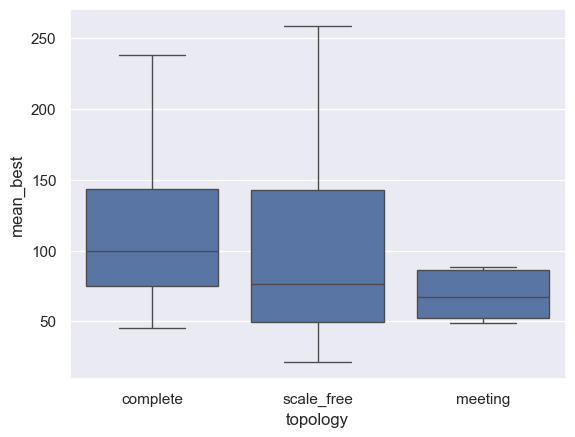

In [32]:
sns.boxplot(
    data=comparison,
    x="topology",
    y="mean_best"
)

In [40]:
# Tylko dla 500 wysp
comparison[comparison["number_of_islands"]==500]


,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg,config_id
4,complete,500,45.596358,4.764631,42.093114,52.269432,42.470960,65.262122,17.756350,52.482854,94.491498,57.367060,NaN
14,scale_free,500,24.137909,2.955835,20.701186,28.784801,23.315194,99.441686,7.250177,93.906362,110.604909,94.846973,500_500_5_15_14
15,scale_free,500,22.791094,3.448255,17.599991,26.660705,22.671722,92.087622,10.744423,78.946079,100.608175,98.609856,500_500_5_20_18
16,scale_free,500,21.118891,2.659887,18.253427,23.914107,22.544211,83.752959,1.490149,82.498808,85.411672,83.018504,500_500_5_20_19
23,meeting,500,48.784184,1.536924,47.183104,50.902658,48.553628,62.258990,0.939375,61.446657,63.818691,62.138087,500_500_5_10_1000_0.0005_1.0_0.005
24,meeting,500,51.875437,6.818036,41.710437,59.755573,54.222845,68.962387,7.343636,58.553682,74.443058,73.703726,500_500_5_10_1000_0.001_1.0_0.005
25,meeting,500,53.781570,3.517976,50.116776,57.113170,54.447959,63.589115,3.069008,60.220258,65.926875,65.632274,500_500_5_10_500_0.001_1.0_0.001


# Porównanie 3 najlepszych konfiguracji dla różnej liczby wysp

In [33]:
df_compare = pd.concat([df_complete, df_meeting, df_scale_free])
df_compare

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,average,best,source_file,z_star,n_steps,r0,r1,gamma,build_target_ratio,seed,config_id,m0,m
0,20,complete,500,5,5,52.482854,42.093114,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21,complete,500,5,5,52.482854,42.093114,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22,complete,500,5,5,94.491498,52.269432,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,23,complete,500,5,5,57.367060,42.470960,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24,complete,500,5,5,69.486343,49.055172,complete_n500_array_20315054.csv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,55,scale_free,100,5,5,179.184287,127.277825,scale_free_n100_array_20313659.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,100_100_5_20_13,20.0,13.0
71,56,scale_free,100,5,5,212.740723,145.044397,scale_free_n100_array_20313659.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,100_100_5_20_13,20.0,13.0
72,59,scale_free,100,5,5,212.892030,139.555531,scale_free_n100_array_20313659.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,100_100_5_20_13,20.0,13.0
73,57,scale_free,100,5,5,210.908170,135.158048,scale_free_n100_array_20313659.csv,NaN,NaN,NaN,NaN,NaN,NaN,123.0,100_100_5_20_13,20.0,13.0


In [34]:
df_islands_compare = (
    df_compare.groupby(
        ["topology", "number_of_islands"],
        as_index=False
    )
    .agg(
        mean_best=("best", "mean"),
        std_best=("best", "std"),
        min_best=("best", "min"),
        max_best=("best", "max"),
        median_best=("best", "median"),
        mean_avg=("average", "mean"),
        std_avg=("average", "std"),
        min_avg=("average", "min"),
        max_avg=("average", "max"),
        median_avg=("average", "median"),
    )
)

display(df_islands_compare)

,topology,number_of_islands,mean_best,std_best,min_best,max_best,median_best,mean_avg,std_avg,min_avg,max_avg,median_avg
0,complete,50,238.240552,2.273440,235.777742,240.158113,239.331050,269.214739,2.023646,265.703022,270.727155,269.886729
1,complete,100,143.733269,7.957138,137.144861,152.621582,139.622431,195.639476,5.798808,188.735106,202.246417,195.439627
2,complete,200,99.548170,2.318905,95.921994,101.343986,100.542587,145.865687,4.230812,139.420650,150.167057,147.732975
3,complete,300,75.328563,9.453703,65.645665,87.388268,70.234101,102.361683,21.582584,82.305031,137.123448,101.678400
4,complete,500,45.596358,4.764631,42.093114,52.269432,42.470960,65.262122,17.756350,52.482854,94.491498,57.367060
5,meeting,300,85.936948,6.922605,75.975925,97.149535,85.283691,110.897036,10.292213,95.550640,125.707431,110.932109
6,meeting,500,51.480397,4.694227,41.710437,59.755573,50.116776,64.936831,5.229602,58.553682,74.443058,63.818691
7,scale_free,50,243.530565,18.907130,204.120437,272.357989,242.815296,269.982716,22.180081,227.981058,301.758976,274.965411
8,scale_free,100,140.486631,9.702970,126.880463,154.129889,139.678178,198.320635,13.471481,176.294838,214.540411,202.108526
9,scale_free,200,77.731212,5.511791,69.568359,90.291510,79.036419,146.773494,8.798784,129.653547,158.129228,147.098527


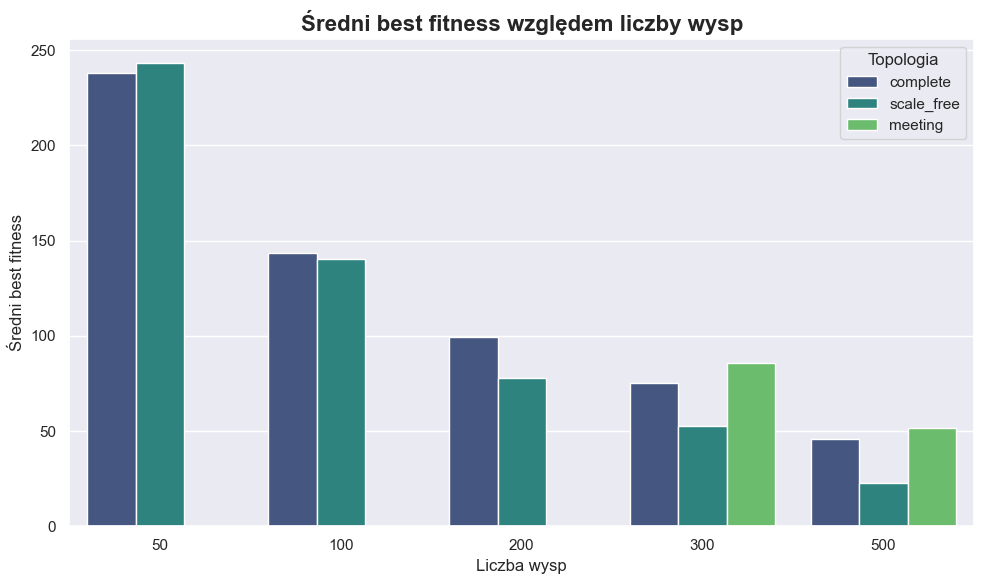

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="mean_best",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Średni best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

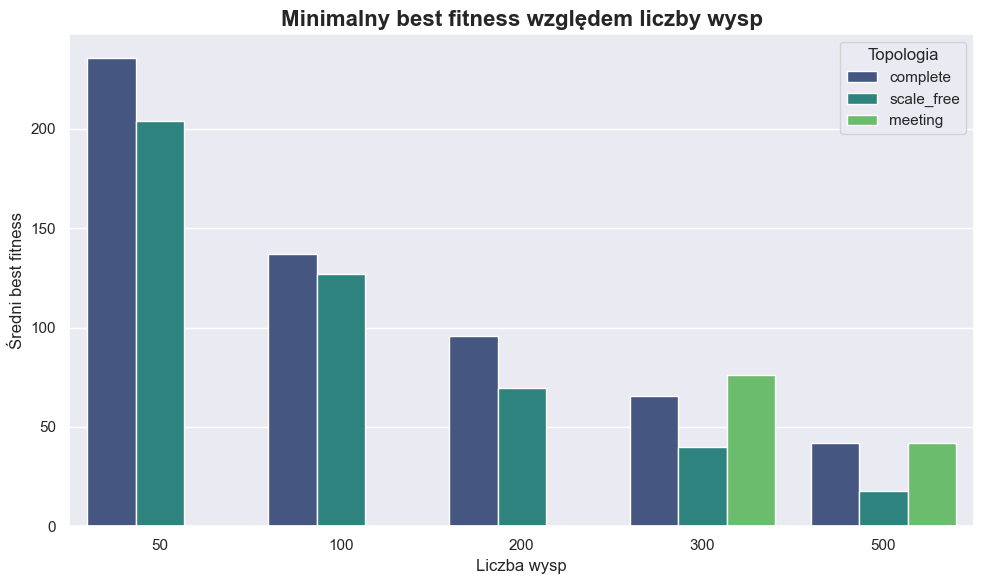

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="min_best",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Minimalny best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

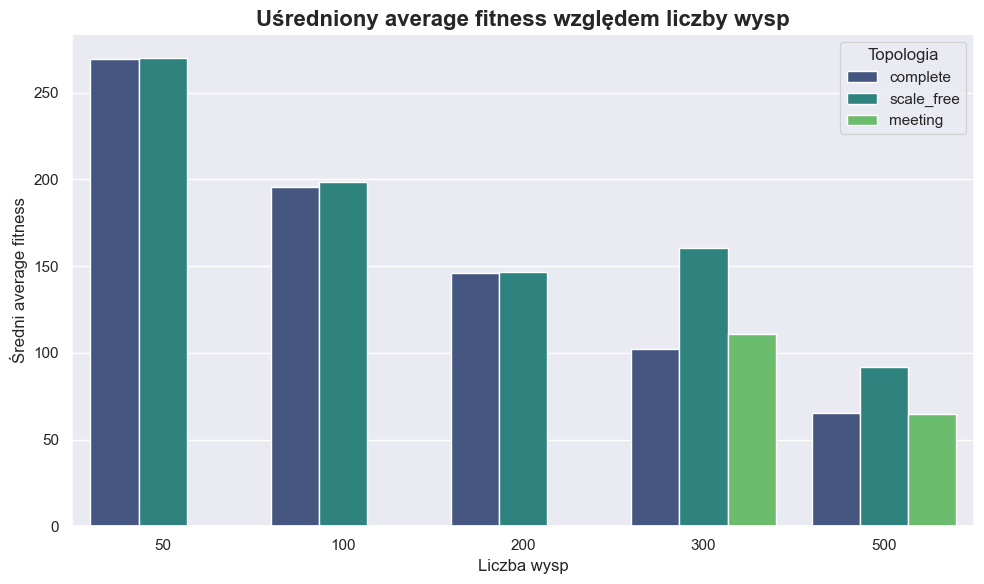

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="mean_avg",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Uśredniony average fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni average fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()